Tables created: products, dates, sales

ROLAP Results:
       category  avg_revenue
0     Clothing        155.0
1  Electronics       1000.0
2         Toys         80.0


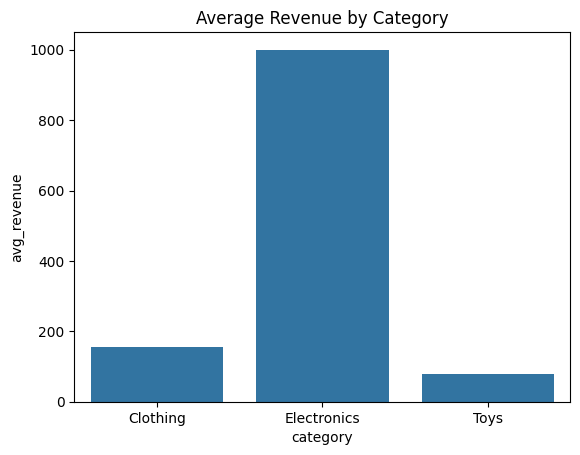


MOLAP Cube:
 year           2024   2025
category                  
Clothing      150.0  160.0
Electronics  2000.0    NaN
Toys            NaN   80.0


C:\Users\USER\AppData\Local\Temp\ipykernel_9400\1902546222.py:81: FutureWarning: The provided callable <function sum at 0x000001D992122160> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  molap_cube = pd.pivot_table(


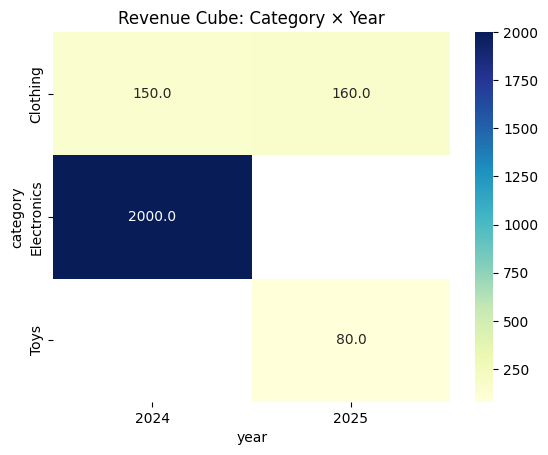


HOLAP Summary (2024):
       category  revenue
0     Clothing      150
1  Electronics     2000


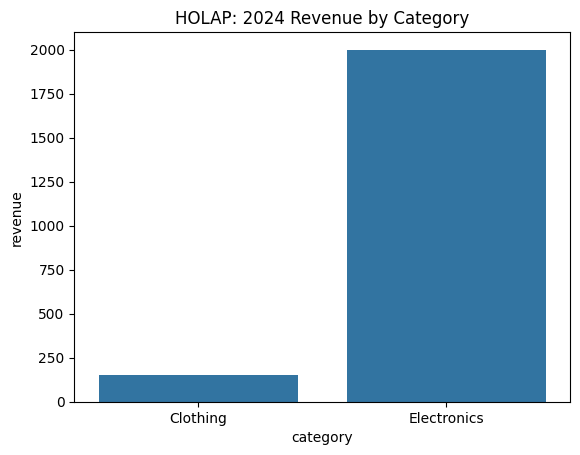


Slice (2024 sales):
    sale_id        date  product_id  quantity  revenue     category  year  \
0        1  2024-01-15           1         2     1000  Electronics  2024   
1        2  2024-03-20           2         1     1000  Electronics  2024   
2        3  2024-05-10           3         3      150     Clothing  2024   

   quarter  month  
0        1      1  
1        1      3  
2        2      5  

Dice (Q1 2024, Electronics):
    sale_id        date  product_id  quantity  revenue     category  year  \
0        1  2024-01-15           1         2     1000  Electronics  2024   
1        2  2024-03-20           2         1     1000  Electronics  2024   

   quarter  month  
0        1      1  
1        1      3  

Roll-Up (Total Revenue by Category):
       category  revenue
0     Clothing      310
1  Electronics     2000
2         Toys       80


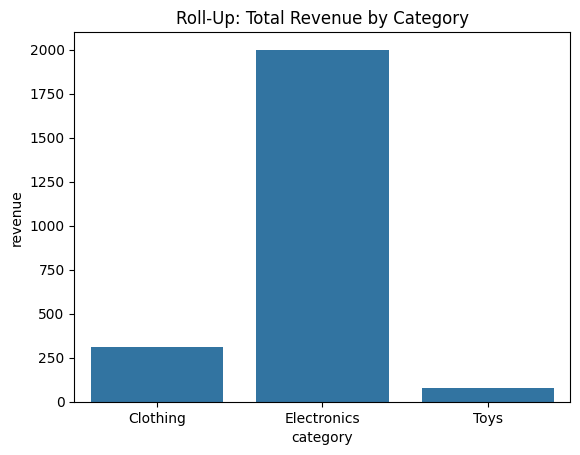


Drill-Down (Year → Month):
    year  month  revenue
0  2024      1     1000
1  2024      3     1000
2  2024      5      150
3  2025      2      160
4  2025      7       80


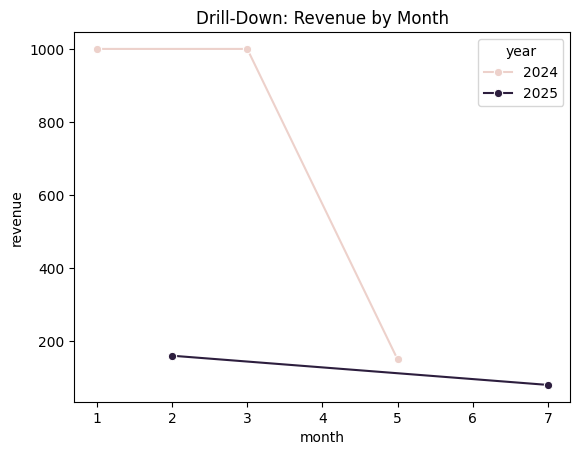

In [ ]:
#  mini OLAP system


import pandas as pd
import numpy as np
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

# ================================
# Database connection
# ================================
def create_connection(db_file=":memory:"):
    return sqlite3.connect(db_file)

conn = create_connection()

# ================================
# Create sample star schema
# ================================
# Products dimension
products = pd.DataFrame({
    'product_id': [1, 2, 3, 4, 5, 6],
    'category': ['Electronics','Electronics','Clothing','Clothing','Toys','Home'],
    'name': ['Phone','Laptop','Shirt','Dress','Puzzle','Sofa'],
    'price': [500, 1000, 50, 80, 20, 300]
})

# Dates dimension
dates = pd.DataFrame({
    'date': ['2024-01-15','2024-03-20','2024-05-10','2025-02-18','2025-07-22'],
    'year': [2024,2024,2024,2025,2025],
    'quarter': [1,1,2,1,3],
    'month': [1,3,5,2,7]
})

# Fact table: sales
sales = pd.DataFrame({
    'sale_id': [1,2,3,4,5],
    'date': ['2024-01-15','2024-03-20','2024-05-10','2025-02-18','2025-07-22'],
    'product_id': [1,2,3,4,5],
    'quantity': [2,1,3,2,4],
    'revenue': [1000,1000,150,160,80]
})

# Load tables into SQLite
products.to_sql('products', conn, if_exists='replace', index=False)
dates.to_sql('dates', conn, if_exists='replace', index=False)
sales.to_sql('sales', conn, if_exists='replace', index=False)

print("Tables created: products, dates, sales")

# ================================
# ROLAP Queries
# ================================
# 1. Average revenue by product category
rolap_query = """
SELECT p.category, AVG(s.revenue) as avg_revenue
FROM sales s
JOIN products p ON s.product_id = p.product_id
GROUP BY p.category
"""
rolap_results = pd.read_sql_query(rolap_query, conn)
print("\nROLAP Results:\n", rolap_results)

# Visualization
sns.barplot(x='category', y='avg_revenue', data=rolap_results)
plt.title("Average Revenue by Category")
plt.show()

# ================================
# MOLAP (Pivot table in pandas)
# ================================
sales_df = pd.read_sql_query("""
SELECT s.*, p.category, d.year, d.quarter, d.month
FROM sales s
JOIN products p ON s.product_id = p.product_id
JOIN dates d ON s.date = d.date
""", conn)

molap_cube = pd.pivot_table(
    sales_df,
    values='revenue',
    index=['category'],
    columns=['year'],
    aggfunc=np.sum
)

print("\nMOLAP Cube:\n", molap_cube)

# Visualization
sns.heatmap(molap_cube, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Revenue Cube: Category × Year")
plt.show()

# ================================
# HOLAP (SQL + Pandas)
# ================================
holap_sql = """
SELECT s.date, s.revenue, p.category, d.year
FROM sales s
JOIN products p ON s.product_id = p.product_id
JOIN dates d ON s.date = d.date
WHERE d.year = 2024
"""
detail_df = pd.read_sql_query(holap_sql, conn)
holap_summary = detail_df.groupby('category')['revenue'].sum().reset_index()
print("\nHOLAP Summary (2024):\n", holap_summary)

sns.barplot(data=holap_summary, x='category', y='revenue')
plt.title("HOLAP: 2024 Revenue by Category")
plt.show()

# ================================
# OLAP Operations
# ================================
# Slice: 2024 only
slice_df = sales_df[sales_df['year']==2024]
print("\nSlice (2024 sales):\n", slice_df)

# Dice: Electronics in Q1 2024
dice_df = sales_df[(sales_df['year']==2024) & (sales_df['quarter']==1) & (sales_df['category']=='Electronics')]
print("\nDice (Q1 2024, Electronics):\n", dice_df)

# Roll-Up: Product -> Category
rollup_df = sales_df.groupby('category')['revenue'].sum().reset_index()
print("\nRoll-Up (Total Revenue by Category):\n", rollup_df)
sns.barplot(data=rollup_df, x='category', y='revenue')
plt.title("Roll-Up: Total Revenue by Category")
plt.show()

# Drill-Down: Year -> Month
drilldown_df = sales_df.groupby(['year','month'])['revenue'].sum().reset_index()
print("\nDrill-Down (Year → Month):\n", drilldown_df)
sns.lineplot(data=drilldown_df, x='month', y='revenue', hue='year', marker='o')
plt.title("Drill-Down: Revenue by Month")
plt.show()
